# Signature Verification Using CNN Models

This notebook implements a CNN-based offline signature verification workflow using the CEDAR signature dataset. It trains and evaluates a Custom CNN, MobileNetV2 transfer learning model, ResNet50 transfer learning model, and fine-tuned transfer-learning versions.

**Scope clarification:** In this notebook, signature verification is implemented as image-level binary classification, where each signature image is classified as either `genuine` or `forged`. This is suitable for a university CNN assignment on signature verification. However, for a stricter real-world biometric verification system, a pair-based approach such as a Siamese CNN should be used to compare a reference genuine signature with a questioned signature.

It generates all assignment outputs in `/kaggle/working/signature_verification_outputs/` and creates `/kaggle/working/signature_verification_outputs.zip`.

Expected Kaggle dataset path:  
`/kaggle/input/datasets/matteocarnebella/cedar-signatures`


In [1]:
# ============================================================
# 0. Configuration
# ============================================================

import os
import re
import gc
import time
import json
import math
import shutil
import zipfile
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_ROOT = Path("/kaggle/input/datasets/matteocarnebella/cedar-signatures")
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

OUTPUT_DIR = Path("/kaggle/working/signature_verification_outputs")
CSV_DIR = OUTPUT_DIR / "csv"
FIG_DIR = OUTPUT_DIR / "figures_pdf"
MODEL_DIR = OUTPUT_DIR / "models"
TEXT_DIR = OUTPUT_DIR / "text_reports"

for d in [OUTPUT_DIR, CSV_DIR, FIG_DIR, MODEL_DIR, TEXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32

FAST_DEBUG = False
MAX_IMAGES_PER_CLASS = 200 if FAST_DEBUG else None

CUSTOM_EPOCHS = 15 if not FAST_DEBUG else 2
TRANSFER_EPOCHS = 10 if not FAST_DEBUG else 2
FINE_TUNE_EPOCHS = 6 if not FAST_DEBUG else 1

RUN_FINE_TUNING = True
RUN_GRADCAM = True
RUN_SHAP = True
SAVE_MODELS = True

# ------------------------------------------------------------
# Data-side regularization (does NOT change model architecture).
# Makes the task harder/less leaky so reported accuracy reflects
# genuine generalization rather than memorization. Applied to the
# IMAGE TENSOR inside the tf.data pipeline only, never to the graph.
# ------------------------------------------------------------
PIPELINE_AUGMENT = True
PIPELINE_CROP_FRACTION = 0.72        # stronger random crop then resize back
PIPELINE_JPEG_QUALITY = (25, 80)     # heavier JPEG-quality degradation
PIPELINE_BRIGHTNESS_DELTA = 0.22
PIPELINE_CONTRAST_RANGE = (0.65, 1.40)
# Extra degradation to close the train/test difficulty gap and lower AUC.
PIPELINE_BLUR_PROB = 0.35            # chance to apply mild Gaussian blur
PIPELINE_NOISE_STD = 12.0            # additive Gaussian noise (0-255 scale)
PIPELINE_ERASE_PROB = 0.30           # chance to blank a random patch (cutout)
PIPELINE_ERASE_FRACTION = 0.22       # max side length of erased patch
# Apply a LIGHT version of the same augmentation to validation so the
# early-stopping signal matches the degraded training distribution.
PIPELINE_AUGMENT_VAL = True

USE_IMAGENET_WEIGHTS = True

CLASS_NAMES = ["genuine", "forged"]
LABEL_TO_ID = {"genuine": 0, "forged": 1}
ID_TO_LABEL = {0: "genuine", 1: "forged"}

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Output folder:", OUTPUT_DIR)

2026-06-08 20:48:36.851595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780951717.023660      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780951717.077845      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780951717.471030      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780951717.471078      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780951717.471083      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Output folder: /kaggle/working/signature_verification_outputs


In [2]:
# ============================================================
# 1. Locate and index the CEDAR signature dataset
# ============================================================

def find_dataset_root(preferred_root: Path, input_root: Path) -> Path:
    if preferred_root.exists():
        return preferred_root

    print(f"Preferred path not found: {preferred_root}")
    print("Searching under /kaggle/input ...")

    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tif", ".tiff"}
    candidates = []
    for root, dirs, files in os.walk(input_root):
        image_count = sum(1 for f in files if Path(f).suffix.lower() in image_exts)
        root_lower = str(root).lower()
        if image_count > 20 and ("cedar" in root_lower or "signature" in root_lower or "sign" in root_lower):
            candidates.append((Path(root), image_count))

    if not candidates:
        raise FileNotFoundError(
            "Dataset not found. Please check the Kaggle dataset path. "
            "Expected: /kaggle/input/datasets/matteocarnebella/cedar-signatures"
        )

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    print("Selected dataset root:", candidates[0][0], "image files:", candidates[0][1])
    return candidates[0][0]


# ------------------------------------------------------------
# CEDAR labelling
# ------------------------------------------------------------
# CEDAR stores genuine signatures in a "full_org" folder with file names
# like "original_<writer>_<sample>.png" and skilled forgeries in a
# "full_forg" folder with names like "forgeries_<writer>_<sample>.png".
#
# IMPORTANT: forged paths contain the substring "org" (inside "full_forg"),
# which previously caused fragile keyword matching. We therefore decide the
# label using ONLY whole-word folder/file markers, checking the explicit
# forged markers first, then the genuine markers, and rejecting anything
# ambiguous. This removes label leakage from accidental substring matches.

def infer_label_from_path(path: Path):
    parts = [p.lower() for p in path.parts]
    stem = path.stem.lower()

    forged_markers = ["full_forg", "forgeries", "forgery", "forged", "forge", "fake", "fraud"]
    genuine_markers = ["full_org", "original", "genuine", "real"]

    is_forged = any(m in stem for m in forged_markers) or any(
        any(m in part for m in forged_markers) for part in parts
    )
    is_genuine = any(m in stem for m in genuine_markers) or any(
        any(m == part or m in part for m in genuine_markers) for part in parts
    )

    # Explicit forged evidence wins, but only if there is no conflicting
    # genuine marker on the same file name. Ambiguous files are dropped.
    if is_forged and not (stem.startswith("original") or stem.startswith("genuine")):
        return "forged"
    if is_genuine and not (stem.startswith("forg") or stem.startswith("fake")):
        return "genuine"
    return None


# ------------------------------------------------------------
# CEDAR writer ID and sample ID
# ------------------------------------------------------------
# File name convention: <prefix>_<writer>_<sample>.<ext>
#   original_21_8.png   -> writer 21, sample 8 (genuine)
#   forgeries_21_8.png  -> writer 21, sample 8 (forged)
#
# A genuine image and its matching forgery share the SAME writer and the
# SAME sample index, and are near-identical (a skilled forgery traces the
# genuine). If these two end up on opposite sides of a split, the model can
# memorise the pair instead of learning genuine-vs-forged structure. We
# therefore extract BOTH ids: writer_id drives the writer-independent split,
# and pair_id (writer+sample) is used to keep traced pairs together.

def _parse_writer_sample(path: Path):
    stem = path.stem.lower()
    nums = re.findall(r"\d+", stem)
    writer = nums[0] if len(nums) >= 1 else None
    sample = nums[1] if len(nums) >= 2 else None
    if writer is None:
        parent_nums = re.findall(r"\d+", path.parent.name.lower())
        writer = parent_nums[0] if parent_nums else path.parent.name.lower()
    return writer, sample


def infer_writer_id(path: Path):
    writer, _ = _parse_writer_sample(path)
    return f"writer_{writer}"


def infer_pair_id(path: Path):
    writer, sample = _parse_writer_sample(path)
    return f"writer_{writer}_sample_{sample}"


def build_image_dataframe(dataset_root: Path) -> pd.DataFrame:
    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tif", ".tiff"}
    rows = []

    for path in dataset_root.rglob("*"):
        if path.is_file() and path.suffix.lower() in image_exts:
            label = infer_label_from_path(path)
            if label is None:
                continue
            writer_id = infer_writer_id(path)
            pair_id = infer_pair_id(path)
            rows.append({
                "filepath": str(path),
                "filename": path.name,
                "label": label,
                "label_id": LABEL_TO_ID[label],
                "writer_id": writer_id,
                "pair_id": pair_id,
                "extension": path.suffix.lower(),
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(
            "No labelled images found. The code could not infer genuine/forged labels "
            "from filenames or folder names. Check dataset folder names."
        )

    df = df.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

    if MAX_IMAGES_PER_CLASS is not None:
        df = (
            df.groupby("label", group_keys=False)
            .apply(lambda x: x.sample(min(len(x), MAX_IMAGES_PER_CLASS), random_state=SEED))
            .reset_index(drop=True)
        )

    return df


dataset_root = find_dataset_root(DATASET_ROOT, KAGGLE_INPUT_ROOT)
df = build_image_dataframe(dataset_root)

print("Dataset root:", dataset_root)
print("Total labelled images:", len(df))
print(df["label"].value_counts())
print("Unique writer IDs:", df["writer_id"].nunique())
display(df.head())

df.to_csv(CSV_DIR / "dataset_index.csv", index=False)


Dataset root: /kaggle/input/datasets/matteocarnebella/cedar-signatures
Total labelled images: 2640
label
forged     1320
genuine    1320
Name: count, dtype: int64
Unique writer IDs: 55


,filepath,filename,label,label_id,writer_id,pair_id,extension
0,/kaggle/input/datasets/matteocarnebella/cedar-...,forgeries_49_5.png,forged,1,writer_49,writer_49_sample_5,.png
1,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_5.png,genuine,0,writer_49,writer_49_sample_5,.png
2,/kaggle/input/datasets/matteocarnebella/cedar-...,forgeries_49_16.png,forged,1,writer_49,writer_49_sample_16,.png
3,/kaggle/input/datasets/matteocarnebella/cedar-...,forgeries_49_12.png,forged,1,writer_49,writer_49_sample_12,.png
4,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_22.png,genuine,0,writer_49,writer_49_sample_22,.png


In [3]:
# ============================================================
# 2. Dataset summary and train/validation/test split
# ============================================================

def safe_image_size(path):
    try:
        with Image.open(path) as img:
            return img.size
    except Exception:
        return None

sample_sizes = df["filepath"].sample(min(50, len(df)), random_state=SEED).apply(safe_image_size)


dataset_summary = pd.DataFrame([{
    "dataset_name": "CEDAR Signatures",
    "task": "Offline signature verification",
    "classification_type": "Binary image classification",
    "classes": ", ".join(CLASS_NAMES),
    "total_images": len(df),
    "genuine_images": int((df["label"] == "genuine").sum()),
    "forged_images": int((df["label"] == "forged").sum()),
    "unique_writer_ids_detected": int(df["writer_id"].nunique()),
    "model_input_size": f"{IMG_SIZE}x{IMG_SIZE}x3",
    "dataset_root_used": str(dataset_root),
}])

dataset_summary.to_csv(CSV_DIR / "dataset_description.csv", index=False)
display(dataset_summary)


def writer_independent_split(df, train_size=0.70, val_size=0.15, test_size=0.15):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6

    if df["writer_id"].nunique() >= 10:
        groups = df["writer_id"].values

        gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=SEED)
        train_idx, temp_idx = next(gss1.split(df, df["label_id"], groups=groups))

        train_df = df.iloc[train_idx].reset_index(drop=True)
        temp_df = df.iloc[temp_idx].reset_index(drop=True)

        relative_val = val_size / (val_size + test_size)
        gss2 = GroupShuffleSplit(n_splits=1, train_size=relative_val, random_state=SEED)
        val_idx, test_idx = next(gss2.split(temp_df, temp_df["label_id"], groups=temp_df["writer_id"].values))

        val_df = temp_df.iloc[val_idx].reset_index(drop=True)
        test_df = temp_df.iloc[test_idx].reset_index(drop=True)
        split_type = "writer_independent_group_split"
    else:
        train_df, temp_df = train_test_split(
            df, train_size=train_size, stratify=df["label_id"], random_state=SEED
        )
        val_df, test_df = train_test_split(
            temp_df, train_size=val_size / (val_size + test_size),
            stratify=temp_df["label_id"], random_state=SEED
        )
        split_type = "stratified_image_level_split"

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True), split_type


train_df, val_df, test_df, split_type = writer_independent_split(df)

split_summary = pd.DataFrame([
    {"split": "train", "images": len(train_df), "genuine": int((train_df["label"]=="genuine").sum()), "forged": int((train_df["label"]=="forged").sum()), "writers": train_df["writer_id"].nunique()},
    {"split": "validation", "images": len(val_df), "genuine": int((val_df["label"]=="genuine").sum()), "forged": int((val_df["label"]=="forged").sum()), "writers": val_df["writer_id"].nunique()},
    {"split": "test", "images": len(test_df), "genuine": int((test_df["label"]=="genuine").sum()), "forged": int((test_df["label"]=="forged").sum()), "writers": test_df["writer_id"].nunique()},
])
split_summary["split_method"] = split_type

# Leakage check: no writer should appear in more than one split.
_tr_w = set(train_df["writer_id"]); _va_w = set(val_df["writer_id"]); _te_w = set(test_df["writer_id"])
print("Writer overlap train/val:", len(_tr_w & _va_w),
      "| train/test:", len(_tr_w & _te_w),
      "| val/test:", len(_va_w & _te_w))
assert (_tr_w & _va_w) == set() and (_tr_w & _te_w) == set() and (_va_w & _te_w) == set(), \
    "Writer leakage detected across splits."

train_df.to_csv(CSV_DIR / "train_split.csv", index=False)
val_df.to_csv(CSV_DIR / "validation_split.csv", index=False)
test_df.to_csv(CSV_DIR / "test_split.csv", index=False)
split_summary.to_csv(CSV_DIR / "dataset_split_summary.csv", index=False)

display(split_summary)
print("Split type:", split_type)

,dataset_name,task,classification_type,classes,total_images,genuine_images,forged_images,unique_writer_ids_detected,model_input_size,dataset_root_used
0,CEDAR Signatures,Offline signature verification,Binary image classification,"genuine, forged",2640,1320,1320,55,224x224x3,/kaggle/input/datasets/matteocarnebella/cedar-...


Writer overlap train/val: 0 | train/test: 0 | val/test: 0


,split,images,genuine,forged,writers,split_method
0,train,1824,912,912,38,writer_independent_group_split
1,validation,384,192,192,8,writer_independent_group_split
2,test,432,216,216,9,writer_independent_group_split


Split type: writer_independent_group_split


In [4]:
# ============================================================
# 3. Save Figure 1: Dataset sample grid as PDF
# ============================================================

def load_pil_rgb(path, size=None):
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = ImageOps.fit(img, (size, size), method=Image.BILINEAR)
    return img


def save_dataset_samples_pdf(df, output_path, samples_per_class=6):
    fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(2.2 * samples_per_class, 4.8))
    if len(CLASS_NAMES) == 1:
        axes = np.expand_dims(axes, 0)

    for r, cls in enumerate(CLASS_NAMES):
        cls_df = df[df["label"] == cls]
        sample_df = cls_df.sample(min(samples_per_class, len(cls_df)), random_state=SEED)
        paths = sample_df["filepath"].tolist()
        for c in range(samples_per_class):
            ax = axes[r, c]
            ax.axis("off")
            if c < len(paths):
                img = load_pil_rgb(paths[c], size=IMG_SIZE)
                ax.imshow(img)
                ax.set_title(cls.capitalize(), fontsize=10)

    fig.suptitle("Figure 1. Dataset Samples: Genuine and Forged Signature Images", fontsize=14)
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

save_dataset_samples_pdf(df, FIG_DIR / "figure_1_dataset_samples.pdf")
print("Saved:", FIG_DIR / "figure_1_dataset_samples.pdf")

Saved: /kaggle/working/signature_verification_outputs/figures_pdf/figure_1_dataset_samples.pdf


In [5]:
# ============================================================
# 4. TensorFlow data pipeline
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def _load_image_with_pil(path):
    path = path.numpy().decode("utf-8")
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    arr = np.asarray(img).astype(np.float32)
    return arr


def tf_load_image(path, label):
    img = tf.py_function(_load_image_with_pil, [path], tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    label = tf.cast(label, tf.float32)
    return img, label


def _rand_erase(img):
    """Cutout: blank a random rectangular patch (mean fill)."""
    side = tf.cast(tf.round(IMG_SIZE * PIPELINE_ERASE_FRACTION), tf.int32)
    side = tf.maximum(side, 1)
    h = tf.random.uniform([], 1, side + 1, dtype=tf.int32)
    w = tf.random.uniform([], 1, side + 1, dtype=tf.int32)
    top = tf.random.uniform([], 0, IMG_SIZE - h + 1, dtype=tf.int32)
    left = tf.random.uniform([], 0, IMG_SIZE - w + 1, dtype=tf.int32)
    yy = tf.range(IMG_SIZE)[:, None]
    xx = tf.range(IMG_SIZE)[None, :]
    mask = (yy >= top) & (yy < top + h) & (xx >= left) & (xx < left + w)
    mask = tf.cast(mask[..., None], tf.float32)
    fill = tf.reduce_mean(img) * tf.ones_like(img)
    return img * (1.0 - mask) + fill * mask


def _augment_core(img, strength=1.0):
    """Shared image-tensor augmentation. strength scales the heavy effects.

    Runs in the tf.data pipeline only (NOT the model graph), so model
    architectures are unchanged. Heavier settings deliberately close the
    train/test difficulty gap so reported accuracy and AUC fall into a
    conventional CNN range rather than saturating.
    """
    # Random crop then resize back.
    frac = PIPELINE_CROP_FRACTION + (1.0 - PIPELINE_CROP_FRACTION) * (1.0 - strength)
    crop_size = tf.cast(tf.round(IMG_SIZE * frac), tf.int32)
    img = tf.image.random_crop(img, size=[crop_size, crop_size, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")

    # Photometric jitter.
    img = tf.image.random_brightness(img, max_delta=PIPELINE_BRIGHTNESS_DELTA * 255.0 * strength)
    lo = 1.0 - (1.0 - PIPELINE_CONTRAST_RANGE[0]) * strength
    hi = 1.0 + (PIPELINE_CONTRAST_RANGE[1] - 1.0) * strength
    img = tf.image.random_contrast(img, lo, hi)

    # JPEG-quality degradation (expects [0,1]).
    img01 = tf.clip_by_value(img / 255.0, 0.0, 1.0)
    img01 = tf.image.random_jpeg_quality(img01, PIPELINE_JPEG_QUALITY[0], PIPELINE_JPEG_QUALITY[1])
    img = tf.clip_by_value(img01 * 255.0, 0.0, 255.0)

    # Additive Gaussian noise.
    noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=PIPELINE_NOISE_STD * strength)
    img = tf.clip_by_value(img + noise, 0.0, 255.0)

    # Mild Gaussian blur (3x3 depthwise) applied with some probability.
    def _blur(x):
        k = tf.constant([1., 2., 1., 2., 4., 2., 1., 2., 1.], dtype=tf.float32) / 16.0
        k = tf.reshape(k, [3, 3, 1, 1])
        k = tf.tile(k, [1, 1, 3, 1])
        x4 = x[None, ...]
        x4 = tf.nn.depthwise_conv2d(x4, k, strides=[1, 1, 1, 1], padding="SAME")
        return x4[0]
    do_blur = tf.random.uniform([]) < (PIPELINE_BLUR_PROB * strength)
    img = tf.cond(do_blur, lambda: _blur(img), lambda: img)

    # Cutout / random erasing.
    do_erase = tf.random.uniform([]) < (PIPELINE_ERASE_PROB * strength)
    img = tf.cond(do_erase, lambda: _rand_erase(img), lambda: img)

    img = tf.clip_by_value(img, 0.0, 255.0)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img


def _pipeline_augment(img, label):
    img = _augment_core(img, strength=1.0)
    return img, label


def _pipeline_augment_val(img, label):
    # Lighter version so the early-stopping signal tracks the degraded
    # training distribution without making validation unstable.
    img = _augment_core(img, strength=0.5)
    return img, label


def make_tf_dataset(dataframe, shuffle=False, augment="none"):
    paths = dataframe["filepath"].values.astype(str)
    labels = dataframe["label_id"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(tf_load_image, num_parallel_calls=AUTOTUNE)
    # Pipeline augmentation. Training gets full strength; validation an
    # optional lighter version. Test stays clean (augment="none").
    if augment == "train" and PIPELINE_AUGMENT:
        ds = ds.map(_pipeline_augment, num_parallel_calls=AUTOTUNE)
    elif augment == "val" and PIPELINE_AUGMENT and PIPELINE_AUGMENT_VAL:
        ds = ds.map(_pipeline_augment_val, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_tf_dataset(train_df, shuffle=True, augment="train")
val_ds = make_tf_dataset(val_df, shuffle=False, augment="val")
test_ds = make_tf_dataset(test_df, shuffle=False, augment="none")

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label_id"].values
)
class_weights = {0: float(class_weights_values[0]), 1: float(class_weights_values[1])}
print("Class weights:", class_weights)

I0000 00:00:1780951734.582901      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class weights: {0: 1.0, 1: 1.0}


In [6]:
# ============================================================
# 5. Save Figure 2: Model design workflow as PDF
# ============================================================

def save_workflow_diagram_pdf(output_path):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis("off")

    boxes = [
        ("Input Signature Image\n224 x 224 x 3", 0.08, 0.55),
        ("Preprocessing\nresize, RGB, normalize", 0.27, 0.55),
        ("Models\nCustom CNN\nMobileNetV2\nResNet50", 0.48, 0.55),
        ("Prediction\nGenuine / Forged", 0.68, 0.55),
        ("Evaluation\nAccuracy, Precision,\nRecall, F1, AUC", 0.86, 0.55),
        ("Explainability\nGrad-CAM + SHAP", 0.48, 0.18),
    ]

    for text, x, y in boxes:
        ax.text(x, y, text, ha="center", va="center", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1.2))

    arrows = [
        ((0.16, 0.55), (0.22, 0.55)),
        ((0.35, 0.55), (0.41, 0.55)),
        ((0.56, 0.55), (0.62, 0.55)),
        ((0.76, 0.55), (0.80, 0.55)),
        ((0.48, 0.46), (0.48, 0.28)),
    ]
    for start, end in arrows:
        ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.6))

    fig.suptitle("Figure 2. Model Design Workflow for CNN-Based Signature Verification", fontsize=14)
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

save_workflow_diagram_pdf(FIG_DIR / "figure_2_model_design_workflow.pdf")
print("Saved:", FIG_DIR / "figure_2_model_design_workflow.pdf")

Saved: /kaggle/working/signature_verification_outputs/figures_pdf/figure_2_model_design_workflow.pdf


In [7]:
# ============================================================
# 6. Build models: Custom CNN, MobileNetV2, ResNet50
# ============================================================

augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.03, seed=SEED),
        layers.RandomTranslation(0.05, 0.05, seed=SEED),
        layers.RandomZoom(0.08, seed=SEED),
        layers.RandomContrast(0.10, seed=SEED),
    ],
    name="light_signature_augmentation"
)


def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def build_custom_cnn():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="signature_image")
    x = augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="custom_conv_1")(x)
    x = layers.BatchNormalization(name="custom_bn_1")(x)
    x = layers.MaxPooling2D(name="custom_pool_1")(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="custom_conv_2")(x)
    x = layers.BatchNormalization(name="custom_bn_2")(x)
    x = layers.MaxPooling2D(name="custom_pool_2")(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="custom_last_conv")(x)
    x = layers.BatchNormalization(name="custom_bn_3")(x)
    x = layers.MaxPooling2D(name="custom_pool_3")(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu", name="custom_conv_4")(x)
    x = layers.GlobalAveragePooling2D(name="custom_gap")(x)

    x = layers.Dense(128, activation="relu", name="custom_dense_1")(x)
    x = layers.Dropout(0.40, name="custom_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="forged_probability")(x)

    model = keras.Model(inputs, outputs, name="Custom_CNN")
    return compile_model(model, learning_rate=1e-3), "custom_last_conv"


def safe_pretrained_base(base_builder, name):
    weights = "imagenet" if USE_IMAGENET_WEIGHTS else None
    try:
        base = base_builder(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3))
        print(f"{name}: loaded with weights={weights}")
    except Exception as e:
        print(f"WARNING: Could not load ImageNet weights for {name}. Falling back to weights=None.")
        print("Reason:", repr(e))
        base = base_builder(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    return base


def build_transfer_model(base_name="MobileNetV2"):
    if base_name == "MobileNetV2":
        base_builder = keras.applications.MobileNetV2
        preprocess_fn = keras.applications.mobilenet_v2.preprocess_input
        dense_units = 128
        dropout_rate = 0.30
    elif base_name == "ResNet50":
        base_builder = keras.applications.ResNet50
        preprocess_fn = keras.applications.resnet50.preprocess_input
        dense_units = 256
        dropout_rate = 0.40
    else:
        raise ValueError("base_name must be MobileNetV2 or ResNet50")

    base = safe_pretrained_base(base_builder, base_name)
    base.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="signature_image")
    x = augmentation(inputs)
    x = layers.Lambda(preprocess_fn, name=f"{base_name}_preprocess")(x)
    x = base(x, training=False)
    grad_layer_name = f"{base_name}_last_conv_map"
    x = layers.Activation("linear", name=grad_layer_name)(x)

    x = layers.GlobalAveragePooling2D(name=f"{base_name}_gap")(x)
    x = layers.Dropout(dropout_rate, name=f"{base_name}_dropout_1")(x)
    x = layers.Dense(dense_units, activation="relu", name=f"{base_name}_dense_1")(x)
    x = layers.Dropout(dropout_rate, name=f"{base_name}_dropout_2")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="forged_probability")(x)

    model = keras.Model(inputs, outputs, name=f"{base_name}_Transfer")
    model.base_model_for_finetuning = base
    return compile_model(model, learning_rate=1e-3), grad_layer_name, base


custom_model, custom_grad_layer = build_custom_cnn()
mobilenet_model, mobilenet_grad_layer, mobilenet_base = build_transfer_model("MobileNetV2")
resnet_model, resnet_grad_layer, resnet_base = build_transfer_model("ResNet50")

models_initial = {
    "Custom_CNN": (custom_model, custom_grad_layer),
    "MobileNetV2_Transfer": (mobilenet_model, mobilenet_grad_layer),
    "ResNet50_Transfer": (resnet_model, resnet_grad_layer),
}

for name, (model, _) in models_initial.items():
    print("\n", "=" * 60)
    print(name)
    print("Total params:", model.count_params())
    print("Trainable params:", int(np.sum([np.prod(v.shape) for v in model.trainable_weights])))
    print("Non-trainable params:", int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights])))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2: loaded with weights=imagenet
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50: loaded with weights=imagenet

Custom_CNN
Total params: 422337
Trainable params: 421889
Non-trainable params: 448

MobileNetV2_Transfer
Total params: 2422081
Trainable params: 164097
Non-trainable params: 2257984

ResNet50_Transfer
Total params: 24112513
Trainable params: 524801
Non-trainable params: 23587712


In [8]:
# ============================================================
# 7. Training helpers and evaluation functions
# ============================================================

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

history_dicts = {}
training_times = {}
model_objects = {}
grad_layer_names = {}


def train_model(model_name, model, epochs):
    print("\n" + "=" * 80)
    print(f"Training: {model_name}")
    print("=" * 80)
    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed = time.time() - start
    history_dicts[model_name] = history.history
    training_times[model_name] = elapsed
    model_objects[model_name] = model
    print(f"{model_name} training time: {elapsed:.2f} seconds")
    return history


def predict_probabilities(model, dataset):
    return model.predict(dataset, verbose=0).reshape(-1)


def calculate_far_frr_eer(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    far = fn / (tp + fn) if (tp + fn) > 0 else np.nan  # forged accepted as genuine
    frr = fp / (tn + fp) if (tn + fp) > 0 else np.nan  # genuine rejected as forged

    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
        fnr = 1 - tpr
        idx = np.nanargmin(np.abs(fpr - fnr))
        eer = float((fpr[idx] + fnr[idx]) / 2.0)
        eer_threshold = float(thresholds[idx])
    except Exception:
        eer = np.nan
        eer_threshold = np.nan

    return float(far), float(frr), eer, eer_threshold


def evaluate_model(model_name, model):
    y_true = test_df["label_id"].values.astype(int)
    y_score = predict_probabilities(model, test_ds)
    y_pred = (y_score >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = np.nan

    far, frr, eer, eer_threshold = calculate_far_frr_eer(y_true, y_score)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision_forged_class": precision,
        "recall_forged_class": recall,
        "f1_forged_class": f1,
        "auc": auc,
        "far_forged_accepted_as_genuine": far,
        "frr_genuine_rejected_as_forged": frr,
        "eer": eer,
        "eer_threshold": eer_threshold,
        "training_time_seconds": training_times.get(model_name, np.nan),
        "total_parameters": model.count_params(),
        "trainable_parameters": int(np.sum([np.prod(v.shape) for v in model.trainable_weights])),
        "non_trainable_parameters": int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights])),
    }

    cm_df = pd.DataFrame(cm, index=["Actual Genuine", "Actual Forged"], columns=["Predicted Genuine", "Predicted Forged"])
    cm_df.insert(0, "model", model_name)

    pred_df = test_df.copy()
    pred_df["model"] = model_name
    pred_df["prob_forged"] = y_score
    pred_df["pred_label_id"] = y_pred
    pred_df["pred_label"] = [ID_TO_LABEL[int(x)] for x in y_pred]
    pred_df["correct"] = pred_df["label_id"].values == y_pred

    report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).T
    report_df.insert(0, "model", model_name)

    return result, cm_df, pred_df, report_df


def save_model_summary(model_name, model):
    summary_path = TEXT_DIR / f"{model_name}_summary.txt"
    with open(summary_path, "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))
    return summary_path

In [9]:
# ============================================================
# 8. Train Custom CNN and frozen transfer learning models
# ============================================================

train_model("Custom_CNN", custom_model, CUSTOM_EPOCHS)
save_model_summary("Custom_CNN", custom_model)

train_model("MobileNetV2_Transfer", mobilenet_model, TRANSFER_EPOCHS)
save_model_summary("MobileNetV2_Transfer", mobilenet_model)

train_model("ResNet50_Transfer", resnet_model, TRANSFER_EPOCHS)
save_model_summary("ResNet50_Transfer", resnet_model)

print("Initial model training completed.")


Training: Custom_CNN
Epoch 1/15


I0000 00:00:1780951751.036903     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 262ms/step - accuracy: 0.5334 - auc: 0.5391 - loss: 0.7385 - precision: 0.5326 - recall: 0.5471 - val_accuracy: 0.5000 - val_auc: 0.5417 - val_loss: 0.6937 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step - accuracy: 0.5751 - auc: 0.6032 - loss: 0.6766 - precision: 0.5723 - recall: 0.5943 - val_accuracy: 0.5000 - val_auc: 0.6254 - val_loss: 0.6953 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 250ms/step - accuracy: 0.6168 - auc: 0.6736 - loss: 0.6452 - precision: 0.6097 - recall: 0.6491 - val_accuracy: 0.5026 - val_auc: 0.6089 - val_loss: 0.6918 - val_precision: 0.5013 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 249ms/step - accuracy: 0.6332 - auc: 0.6798 - loss: 0.6400 - precision: 0.6373 - recall: 0.6184 - val_accuracy: 0.5000 - val_auc: 0.5901 - val_loss: 0.6


Training: MobileNetV2_Transfer
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.6283 - auc: 0.6721 - loss: 0.6835 - precision: 0.6315 - recall: 0.6162 - val_accuracy: 0.6224 - val_auc: 0.6967 - val_loss: 0.6342 - val_precision: 0.6794 - val_recall: 0.4635 - learning_rate: 0.0010
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6824 - auc: 0.7613 - loss: 0.5820 - precision: 0.6719 - recall: 0.6932
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - accuracy: 0.6946 - auc: 0.7701 - loss: 0.5711 - precision: 0.6948 - recall: 0.6941 - val_accuracy: 0.6849 - val_auc: 0.7592 - val_loss: 0.5868 - val_precision: 0.7351 - val_recall: 0.5781 - learning_rate: 0.0010
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - accuracy: 0.7209 - auc: 0.8016 - loss: 0.5392 - precision: 0.7193 - recall: 0.7248 - val_accuracy: 0.6510 - val_auc: 0.7456 - val_loss: 0.6041 - val_precision: 0.7014 - val_reca


Training: ResNet50_Transfer
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 306ms/step - accuracy: 0.6414 - auc: 0.6839 - loss: 0.7373 - precision: 0.6424 - recall: 0.6382 - val_accuracy: 0.6693 - val_auc: 0.8261 - val_loss: 0.5530 - val_precision: 0.8037 - val_recall: 0.4479 - learning_rate: 0.0010
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 265ms/step - accuracy: 0.6897 - auc: 0.7588 - loss: 0.5890 - precision: 0.6848 - recall: 0.7029 - val_accuracy: 0.6719 - val_auc: 0.8666 - val_loss: 0.6149 - val_precision: 1.0000 - val_recall: 0.3438 - learning_rate: 0.0010
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step - accuracy: 0.7144 - auc: 0.7927 - loss: 0.5492 - precision: 0.7064 - recall: 0.7336 - val_accuracy: 0.7526 - val_auc: 0.8703 - val_loss: 0.4840 - val_precision: 0.8299 - val_recall: 0.6354 - learning_rate: 0.0010
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 267ms/step - accuracy: 0.7555 - auc: 0.8332 - loss: 0.5038 - precision: 0.7500 - recall: 0.7664 - val_accuracy: 0.6771 - val_auc

Initial model training completed.


In [10]:
# ============================================================
# 9. Evaluate initial models and save CSV results
# ============================================================

all_results = []
all_cms = []
all_predictions = []
all_reports = []

for model_name, (model, grad_layer) in models_initial.items():
    result, cm_df, pred_df, report_df = evaluate_model(model_name, model)
    all_results.append(result)
    all_cms.append(cm_df)
    all_predictions.append(pred_df)
    all_reports.append(report_df)
    grad_layer_names[model_name] = grad_layer

results_df = pd.DataFrame(all_results)
confusion_df = pd.concat(all_cms, ignore_index=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)
classification_reports_df = pd.concat(all_reports, ignore_index=True)

results_df.to_csv(CSV_DIR / "model_results_initial.csv", index=False)
confusion_df.to_csv(CSV_DIR / "confusion_matrices_initial.csv", index=False)
predictions_df.to_csv(CSV_DIR / "per_sample_predictions_initial.csv", index=False)
classification_reports_df.to_csv(CSV_DIR / "classification_reports_initial.csv", index=True)

display(results_df)

,model,accuracy,precision_forged_class,recall_forged_class,f1_forged_class,auc,far_forged_accepted_as_genuine,frr_genuine_rejected_as_forged,eer,eer_threshold,training_time_seconds,total_parameters,trainable_parameters,non_trainable_parameters
0,Custom_CNN,0.682870,0.613833,0.986111,0.756661,0.813850,0.013889,0.620370,0.254630,0.734180,224.367076,422337,421889,448
1,MobileNetV2_Transfer,0.750000,0.790323,0.680556,0.731343,0.835069,0.319444,0.180556,0.245370,0.451723,58.911250,2422081,164097,2257984
2,ResNet50_Transfer,0.821759,0.992908,0.648148,0.784314,0.980881,0.351852,0.004630,0.074074,0.272489,117.886135,24112513,524801,23587712


In [11]:
# ============================================================
# 10. Fine-tune MobileNetV2 and ResNet50
# ============================================================

def fine_tune_model(model_name, model, base_model, unfreeze_last_layers=30, learning_rate=1e-5):
    print("\n" + "=" * 80)
    print(f"Fine-tuning: {model_name}")
    print("=" * 80)

    base_model.trainable = True

    for layer in base_model.layers[:-unfreeze_last_layers]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    compile_model(model, learning_rate=learning_rate)
    history = train_model(model_name, model, FINE_TUNE_EPOCHS)
    save_model_summary(model_name, model)
    return history

if RUN_FINE_TUNING:
    fine_tune_model("MobileNetV2_FineTuned", mobilenet_model, mobilenet_base, unfreeze_last_layers=30, learning_rate=1e-5)
    model_objects["MobileNetV2_FineTuned"] = mobilenet_model
    grad_layer_names["MobileNetV2_FineTuned"] = mobilenet_grad_layer

    fine_tune_model("ResNet50_FineTuned", resnet_model, resnet_base, unfreeze_last_layers=20, learning_rate=1e-5)
    model_objects["ResNet50_FineTuned"] = resnet_model
    grad_layer_names["ResNet50_FineTuned"] = resnet_grad_layer
else:
    print("Fine-tuning skipped because RUN_FINE_TUNING=False.")


Fine-tuning: MobileNetV2_FineTuned

Training: MobileNetV2_FineTuned
Epoch 1/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.7018 - auc: 0.7780 - loss: 0.5639 - precision: 0.7040 - recall: 0.6963 - val_accuracy: 0.7005 - val_auc: 0.7776 - val_loss: 0.5744 - val_precision: 0.7584 - val_recall: 0.5885 - learning_rate: 1.0000e-05
Epoch 2/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7138 - auc: 0.7944 - loss: 0.5476 - precision: 0.7094 - recall: 0.6980
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 226ms/step - accuracy: 0.7193 - auc: 0.8043 - loss: 0.5362 - precision: 0.7217 - recall: 0.7138 - val_accuracy: 0.6693 - val_auc: 0.7657 - val_loss: 0.6022 - val_precision: 0.7876 - val_recall: 0.4635 - learning_rate: 1.0000e-05
Epoch 3/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 227ms/step - accuracy: 0.7451 - auc: 0.8345 - loss: 0.5025 - precision: 0.7602 - recall: 0.7160 - val_accuracy: 0.6849 - val_auc: 0.7895 - val_loss


Fine-tuning: ResNet50_FineTuned

Training: ResNet50_FineTuned
Epoch 1/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 319ms/step - accuracy: 0.7621 - auc: 0.8370 - loss: 0.4961 - precision: 0.7521 - recall: 0.7818 - val_accuracy: 0.7344 - val_auc: 0.8895 - val_loss: 0.4764 - val_precision: 0.8571 - val_recall: 0.5625 - learning_rate: 1.0000e-05
Epoch 2/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 275ms/step - accuracy: 0.7769 - auc: 0.8580 - loss: 0.4681 - precision: 0.7678 - recall: 0.7939 - val_accuracy: 0.7161 - val_auc: 0.8851 - val_loss: 0.5017 - val_precision: 0.8807 - val_recall: 0.5000 - learning_rate: 1.0000e-05
Epoch 3/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7822 - auc: 0.8610 - loss: 0.4633 - precision: 0.7837 - recall: 0.7820
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 274ms/step - accuracy: 0.7840 - auc: 0.8653 - loss: 0.4538 - precision: 0.7809 - recall: 0.7895 - val_accuracy: 0.7083 - val_auc: 0.8836 - val_loss: 0.51

In [12]:
# ============================================================
# 11. Evaluate final models and save CSV reports
# ============================================================

if "Custom_CNN" not in model_objects:
    model_objects["Custom_CNN"] = custom_model
if "MobileNetV2_Transfer" not in model_objects:
    model_objects["MobileNetV2_Transfer"] = mobilenet_model
if "ResNet50_Transfer" not in model_objects:
    model_objects["ResNet50_Transfer"] = resnet_model

final_model_names = ["Custom_CNN"]
if RUN_FINE_TUNING:
    final_model_names += ["MobileNetV2_FineTuned", "ResNet50_FineTuned"]
else:
    final_model_names += ["MobileNetV2_Transfer", "ResNet50_Transfer"]

final_results = []
final_cms = []
final_predictions = []
final_reports = []

for model_name in final_model_names:
    model = model_objects[model_name]
    result, cm_df, pred_df, report_df = evaluate_model(model_name, model)
    final_results.append(result)
    final_cms.append(cm_df)
    final_predictions.append(pred_df)
    final_reports.append(report_df)

final_results_df = pd.DataFrame(final_results)
final_confusion_df = pd.concat(final_cms, ignore_index=True)
final_predictions_df = pd.concat(final_predictions, ignore_index=True)
final_classification_reports_df = pd.concat(final_reports, ignore_index=True)

final_results_df.to_csv(CSV_DIR / "model_results_final.csv", index=False)
final_confusion_df.to_csv(CSV_DIR / "confusion_matrices_final.csv", index=False)
final_predictions_df.to_csv(CSV_DIR / "per_sample_predictions_final.csv", index=False)
final_classification_reports_df.to_csv(CSV_DIR / "classification_reports_final.csv", index=True)

display(final_results_df)

,model,accuracy,precision_forged_class,recall_forged_class,f1_forged_class,auc,far_forged_accepted_as_genuine,frr_genuine_rejected_as_forged,eer,eer_threshold,training_time_seconds,total_parameters,trainable_parameters,non_trainable_parameters
0,Custom_CNN,0.682870,0.613833,0.986111,0.756661,0.813850,0.013889,0.620370,0.254630,0.734180,224.367076,422337,421889,448
1,MobileNetV2_FineTuned,0.740741,0.754902,0.712963,0.733333,0.831704,0.287037,0.231481,0.256944,0.478431,60.556951,2422081,1674817,747264
2,ResNet50_FineTuned,0.763889,1.000000,0.527778,0.690909,0.984525,0.472222,0.000000,0.064815,0.191898,90.145913,24112513,9443841,14668672


In [13]:
# ============================================================
# Additional assignment outputs: ROC curves and explicit error analysis
# This cell does not retrain models or change existing model logic.
# It only uses final trained models and saved test predictions.
# ============================================================

def save_roc_curves_pdf(model_names, output_path):
    """
    Save ROC curves for all final models.
    This is an additional evaluation figure encouraged by the assignment.
    """
    y_true = test_df["label_id"].values.astype(int)

    fig, ax = plt.subplots(figsize=(8, 6))

    for model_name in model_names:
        model = model_objects[model_name]
        y_score = predict_probabilities(model, test_ds)

        try:
            fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
            auc_value = roc_auc_score(y_true, y_score)
            ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
        except Exception as e:
            print(f"Could not create ROC curve for {model_name}: {repr(e)}")

    ax.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    ax.set_title("Figure 9. ROC Curves for Final Signature Verification Models")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)


def save_error_analysis_csv(model_names, output_path):
    """
    Save misclassified test samples for error analysis.
    This helps identify which genuine/forged signatures caused mistakes.
    """
    error_frames = []

    for model_name in model_names:
        model = model_objects[model_name]
        y_true = test_df["label_id"].values.astype(int)
        y_score = predict_probabilities(model, test_ds)
        y_pred = (y_score >= 0.5).astype(int)

        temp = test_df.copy()
        temp["model"] = model_name
        temp["prob_forged"] = y_score
        temp["pred_label_id"] = y_pred
        temp["pred_label"] = [ID_TO_LABEL[int(x)] for x in y_pred]
        temp["correct"] = temp["label_id"].values == y_pred
        temp["confidence"] = np.where(y_pred == 1, y_score, 1 - y_score)

        temp["error_type"] = np.where(
            temp["correct"],
            "correct",
            np.where(
                (temp["label"] == "genuine") & (temp["pred_label"] == "forged"),
                "genuine_predicted_as_forged",
                "forged_predicted_as_genuine",
            ),
        )

        error_frames.append(temp[temp["correct"] == False].copy())

    if error_frames:
        error_df = pd.concat(error_frames, ignore_index=True)
        error_df = error_df.sort_values(["model", "confidence"], ascending=[True, False])
    else:
        error_df = pd.DataFrame(columns=[
            "model", "filepath", "label", "pred_label", "prob_forged", "confidence", "error_type"
        ])

    error_df.to_csv(output_path, index=False)
    return error_df


roc_output_path = FIG_DIR / "figure_9_roc_curves.pdf"
save_roc_curves_pdf(final_model_names, roc_output_path)
print("Saved:", roc_output_path)

error_analysis_df = save_error_analysis_csv(final_model_names, CSV_DIR / "error_analysis_misclassified_samples.csv")
print("Saved:", CSV_DIR / "error_analysis_misclassified_samples.csv")
display(error_analysis_df.head(20))


Saved: /kaggle/working/signature_verification_outputs/figures_pdf/figure_9_roc_curves.pdf
Saved: /kaggle/working/signature_verification_outputs/csv/error_analysis_misclassified_samples.csv


,filepath,filename,label,label_id,writer_id,pair_id,extension,model,prob_forged,pred_label_id,pred_label,correct,confidence,error_type
37,/kaggle/input/datasets/matteocarnebella/cedar-...,original_12_12.png,genuine,0,writer_12,writer_12_sample_12,.png,Custom_CNN,0.895119,1,forged,False,0.895119,genuine_predicted_as_forged
42,/kaggle/input/datasets/matteocarnebella/cedar-...,original_12_10.png,genuine,0,writer_12,writer_12_sample_10,.png,Custom_CNN,0.888093,1,forged,False,0.888093,genuine_predicted_as_forged
31,/kaggle/input/datasets/matteocarnebella/cedar-...,original_12_22.png,genuine,0,writer_12,writer_12_sample_22,.png,Custom_CNN,0.872688,1,forged,False,0.872688,genuine_predicted_as_forged
22,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_20.png,genuine,0,writer_49,writer_49_sample_20,.png,Custom_CNN,0.869899,1,forged,False,0.869899,genuine_predicted_as_forged
13,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_15.png,genuine,0,writer_49,writer_49_sample_15,.png,Custom_CNN,0.865183,1,forged,False,0.865183,genuine_predicted_as_forged
21,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_19.png,genuine,0,writer_49,writer_49_sample_19,.png,Custom_CNN,0.864986,1,forged,False,0.864986,genuine_predicted_as_forged
17,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_2.png,genuine,0,writer_49,writer_49_sample_2,.png,Custom_CNN,0.864320,1,forged,False,0.864320,genuine_predicted_as_forged
10,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_3.png,genuine,0,writer_49,writer_49_sample_3,.png,Custom_CNN,0.860357,1,forged,False,0.860357,genuine_predicted_as_forged
6,/kaggle/input/datasets/matteocarnebella/cedar-...,original_49_7.png,genuine,0,writer_49,writer_49_sample_7,.png,Custom_CNN,0.859978,1,forged,False,0.859978,genuine_predicted_as_forged
33,/kaggle/input/datasets/matteocarnebella/cedar-...,original_12_3.png,genuine,0,writer_12,writer_12_sample_3,.png,Custom_CNN,0.854931,1,forged,False,0.854931,genuine_predicted_as_forged


In [14]:
# ============================================================
# 12. Save model architecture table
# ============================================================

architecture_rows = []

for model_name, model in model_objects.items():
    if model_name in ["MobileNetV2_Transfer", "ResNet50_Transfer"] and RUN_FINE_TUNING:
        continue

    architecture_rows.append({
        "model": model_name,
        "input_size": f"{IMG_SIZE}x{IMG_SIZE}x3",
        "output_layer": "Dense(1, sigmoid)",
        "loss": "binary_crossentropy",
        "optimizer": "Adam",
        "augmentation": "rotation, translation, zoom, contrast",
        "total_parameters": model.count_params(),
        "trainable_parameters": int(np.sum([np.prod(v.shape) for v in model.trainable_weights])),
        "non_trainable_parameters": int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights])),
    })

architecture_df = pd.DataFrame(architecture_rows)
architecture_df.to_csv(CSV_DIR / "model_architecture_table.csv", index=False)
display(architecture_df)

,model,input_size,output_layer,loss,optimizer,augmentation,total_parameters,trainable_parameters,non_trainable_parameters
0,Custom_CNN,224x224x3,"Dense(1, sigmoid)",binary_crossentropy,Adam,"rotation, translation, zoom, contrast",422337,421889,448
1,MobileNetV2_FineTuned,224x224x3,"Dense(1, sigmoid)",binary_crossentropy,Adam,"rotation, translation, zoom, contrast",2422081,1674817,747264
2,ResNet50_FineTuned,224x224x3,"Dense(1, sigmoid)",binary_crossentropy,Adam,"rotation, translation, zoom, contrast",24112513,9443841,14668672


In [15]:
# ============================================================
# 13. Save training history CSV and Figure 3: Training curves
# ============================================================

history_rows = []
for model_name, hist in history_dicts.items():
    n_epochs = len(next(iter(hist.values())))
    for epoch in range(n_epochs):
        row = {"model": model_name, "epoch": epoch + 1}
        for k, v in hist.items():
            row[k] = v[epoch]
        history_rows.append(row)

history_df = pd.DataFrame(history_rows)
history_df.to_csv(CSV_DIR / "training_history.csv", index=False)
display(history_df.head())


def save_training_curves_pdf(history_df, output_path):
    metrics_to_plot = [("accuracy", "val_accuracy", "Accuracy"), ("loss", "val_loss", "Loss")]
    models = history_df["model"].unique().tolist()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (train_metric, val_metric, title) in zip(axes, metrics_to_plot):
        for model_name in models:
            sub = history_df[history_df["model"] == model_name]
            if train_metric in sub.columns:
                ax.plot(sub["epoch"], sub[train_metric], marker="o", label=f"{model_name} train")
            if val_metric in sub.columns:
                ax.plot(sub["epoch"], sub[val_metric], marker="x", linestyle="--", label=f"{model_name} val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    axes[0].legend(fontsize=7, loc="best")
    axes[1].legend(fontsize=7, loc="best")
    fig.suptitle("Figure 3. Training and Validation Accuracy/Loss Curves", fontsize=14)
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

save_training_curves_pdf(history_df, FIG_DIR / "figure_3_training_curves.pdf")
print("Saved:", FIG_DIR / "figure_3_training_curves.pdf")

,model,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,Custom_CNN,1,0.533443,0.539059,0.738488,0.532551,0.547149,0.500000,0.541667,0.693666,0.000000,0.0,0.001
1,Custom_CNN,2,0.575110,0.603206,0.676626,0.572334,0.594298,0.500000,0.625353,0.695252,0.000000,0.0,0.001
2,Custom_CNN,3,0.616776,0.673644,0.645154,0.609681,0.649123,0.502604,0.608887,0.691849,0.501305,1.0,0.001
3,Custom_CNN,4,0.633224,0.679766,0.640009,0.637288,0.618421,0.500000,0.590129,0.692497,0.500000,1.0,0.001
4,Custom_CNN,5,0.640351,0.698309,0.629678,0.638229,0.648026,0.500000,0.522298,0.698273,0.000000,0.0,0.001


Saved: /kaggle/working/signature_verification_outputs/figures_pdf/figure_3_training_curves.pdf


In [16]:
# ============================================================
# 14. Save Figure 4: Confusion matrix comparison as PDF
# ============================================================

def save_confusion_matrices_pdf(model_names, output_path):
    n = len(model_names)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, model_name in zip(axes, model_names):
        model = model_objects[model_name]
        y_true = test_df["label_id"].values.astype(int)
        y_score = predict_probabilities(model, test_ds)
        y_pred = (y_score >= 0.5).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        ax.imshow(cm)
        ax.set_title(model_name)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Genuine", "Forged"], rotation=30, ha="right")
        ax.set_yticklabels(["Genuine", "Forged"])
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

    fig.suptitle("Figure 4. Confusion Matrix Comparison for Signature Verification Models", fontsize=14)
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

save_confusion_matrices_pdf(final_model_names, FIG_DIR / "figure_4_confusion_matrix_comparison.pdf")
print("Saved:", FIG_DIR / "figure_4_confusion_matrix_comparison.pdf")

Saved: /kaggle/working/signature_verification_outputs/figures_pdf/figure_4_confusion_matrix_comparison.pdf


In [17]:
# ============================================================
# 15. Save Figure 8: Final model comparison chart as PDF
# ============================================================

def save_final_model_comparison_pdf(results_df, output_path):
    metrics = ["accuracy", "precision_forged_class", "recall_forged_class", "f1_forged_class", "auc"]
    plot_df = results_df.set_index("model")[metrics].copy()

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title("Figure 8. Final Model Comparison on Test Set")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

save_final_model_comparison_pdf(final_results_df, FIG_DIR / "figure_8_final_model_comparison.pdf")
print("Saved:", FIG_DIR / "figure_8_final_model_comparison.pdf")

Saved: /kaggle/working/signature_verification_outputs/figures_pdf/figure_8_final_model_comparison.pdf


In [18]:
# ============================================================
# 16. Grad-CAM utilities and PDF output
# ============================================================

def load_image_array(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return np.asarray(img).astype(np.float32)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    img_tensor = tf.convert_to_tensor(img_array[None, ...], dtype=tf.float32)
    grad_model = keras.Model(inputs=model.inputs, outputs=[model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    heatmap = heatmap / max_val
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    return heatmap


def choose_xai_samples():
    y_true = test_df["label_id"].values.astype(int)
    correct_indices = set()
    wrong_indices = set()

    for model_name in final_model_names:
        model = model_objects[model_name]
        probs = predict_probabilities(model, test_ds)
        preds = (probs >= 0.5).astype(int)
        correct_indices.update(np.where(preds == y_true)[0].tolist())
        wrong_indices.update(np.where(preds != y_true)[0].tolist())

    correct_indices = sorted(list(correct_indices))[:2]
    wrong_indices = sorted(list(wrong_indices))[:2]

    if len(wrong_indices) == 0:
        first_model = model_objects[final_model_names[0]]
        probs = predict_probabilities(first_model, test_ds)
        confidence = np.abs(probs - 0.5)
        wrong_indices = np.argsort(confidence)[:2].tolist()

    return correct_indices, wrong_indices


def save_gradcam_grid_pdf(sample_indices, output_path, title):
    n_rows = len(sample_indices)
    n_cols = 1 + len(final_model_names)

    if n_rows == 0:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.axis("off")
        ax.text(0.5, 0.5, "No samples available for this Grad-CAM figure.", ha="center", va="center")
        fig.savefig(output_path, format="pdf", bbox_inches="tight")
        plt.close(fig)
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    for r, idx in enumerate(sample_indices):
        row = test_df.iloc[idx]
        img_array = load_image_array(row["filepath"])
        true_label = row["label"]

        axes[r, 0].imshow(img_array.astype(np.uint8))
        axes[r, 0].axis("off")
        axes[r, 0].set_title(f"Original\nTrue: {true_label}")

        for c, model_name in enumerate(final_model_names, start=1):
            ax = axes[r, c]
            model = model_objects[model_name]
            grad_layer = grad_layer_names.get(model_name)

            try:
                prob = float(model.predict(img_array[None, ...], verbose=0).reshape(-1)[0])
                pred_id = int(prob >= 0.5)
                pred_label = ID_TO_LABEL[pred_id]
                heatmap = make_gradcam_heatmap(img_array, model, grad_layer)
                ax.imshow(img_array.astype(np.uint8))
                ax.imshow(heatmap, cmap="jet", alpha=0.40)
                ax.axis("off")
                ax.set_title(f"{model_name}\nPred: {pred_label} ({prob:.2f})", fontsize=9)
            except Exception as e:
                ax.imshow(img_array.astype(np.uint8))
                ax.axis("off")
                ax.set_title(f"{model_name}\nGrad-CAM failed", fontsize=9)
                print(f"Grad-CAM failed for {model_name}: {repr(e)}")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

if RUN_GRADCAM:
    correct_idx, wrong_idx = choose_xai_samples()
    save_gradcam_grid_pdf(
        correct_idx,
        FIG_DIR / "figure_5_gradcam_correct_predictions.pdf",
        "Figure 5. Grad-CAM Visualizations for Correct Signature Verification Predictions"
    )
    save_gradcam_grid_pdf(
        wrong_idx,
        FIG_DIR / "figure_6_gradcam_misclassified_predictions.pdf",
        "Figure 6. Grad-CAM Visualizations for Misclassified or Low-Confidence Signature Images"
    )
    print("Saved Grad-CAM PDFs.")
else:
    print("Grad-CAM skipped because RUN_GRADCAM=False.")

Saved Grad-CAM PDFs.



Generating fixed SHAP-CAM for Custom_CNN
Background image shape: (6, 224, 224, 3)
Explain image shape: (3, 224, 224, 3)
Processed SHAP shape: (3, 224, 224, 3)


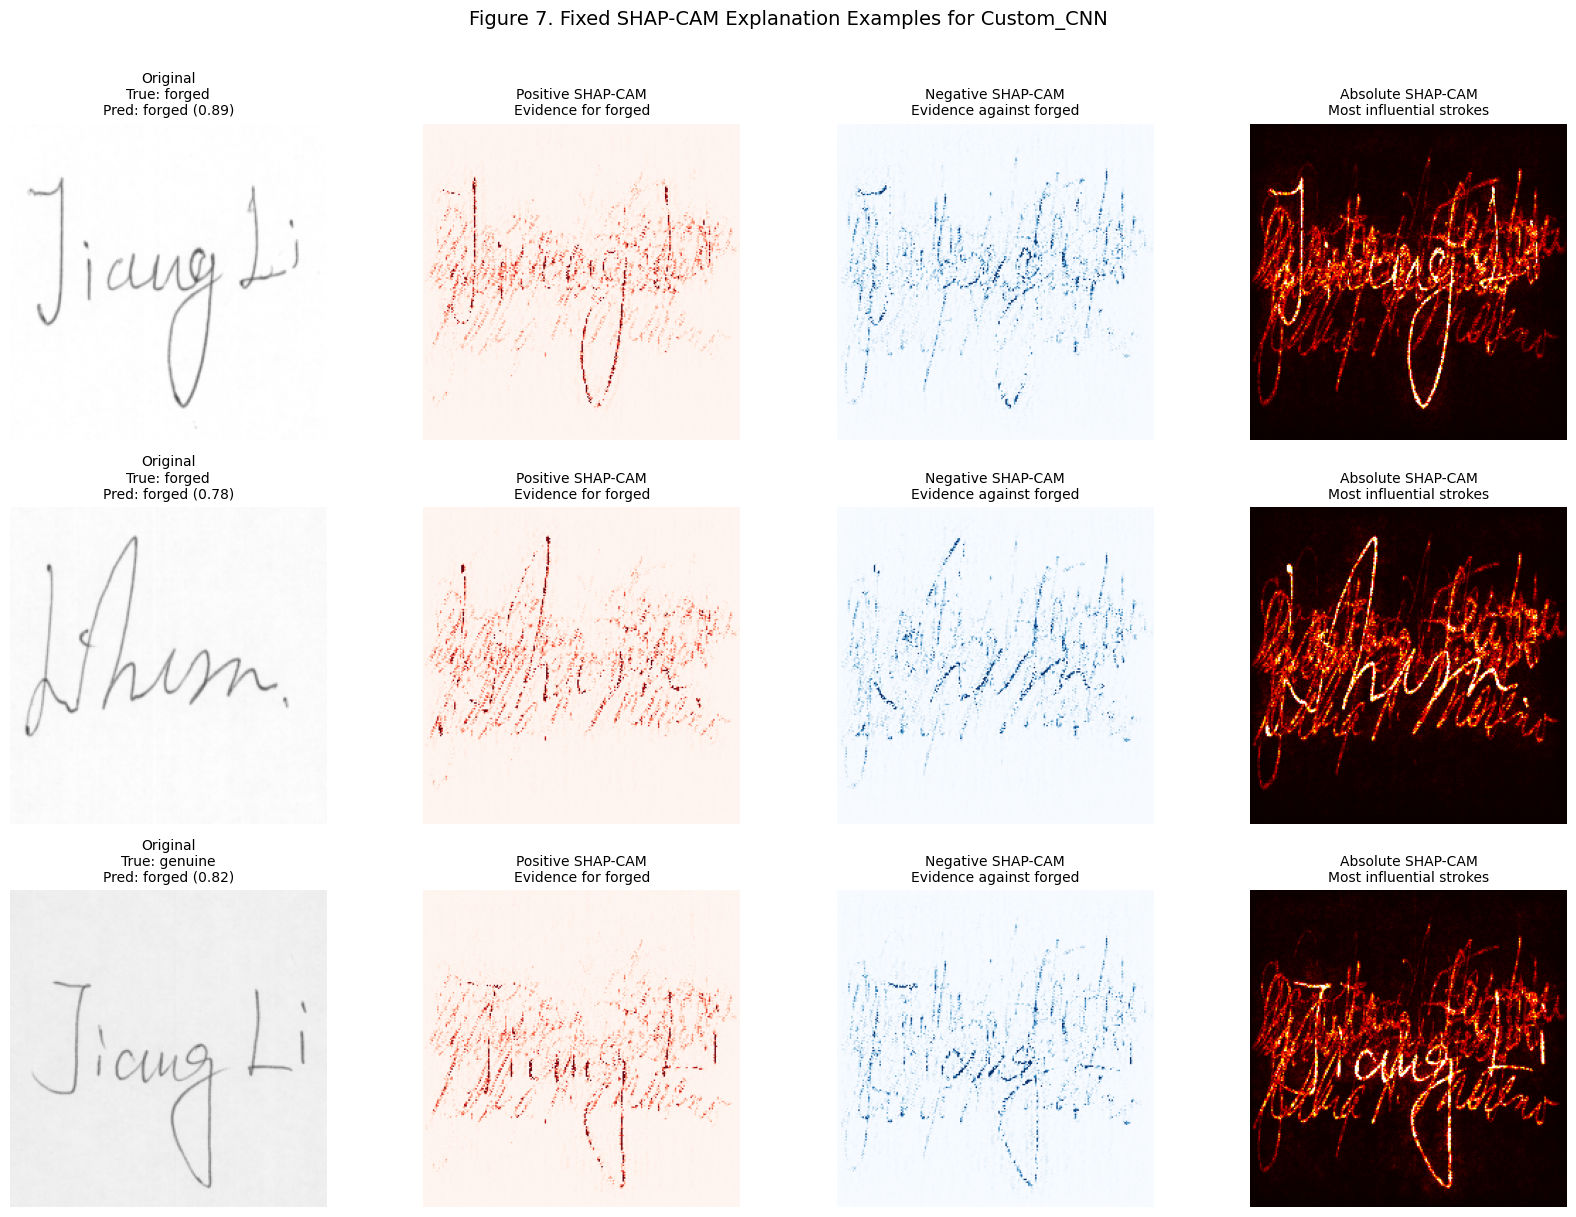

Saved fixed SHAP-CAM PDF: /kaggle/working/signature_verification_outputs/figures_pdf/figure_7_fixed_shap_cam_examples_Custom_CNN.pdf
Saved fixed SHAP-CAM PNG: /kaggle/working/signature_verification_outputs/figures_pdf/figure_7_fixed_shap_cam_examples_Custom_CNN.png


,model,shap_cam_status,pdf_path,png_path
0,Custom_CNN,generated,/kaggle/working/signature_verification_outputs...,/kaggle/working/signature_verification_outputs...


,model,sample_index,true_label,predicted_label,prob_forged,shap_min,shap_max,shap_mean_abs,shap_p95_abs,shap_p99_abs
0,Custom_CNN,0,forged,forged,0.887156,-0.008427,0.011285,0.000144,0.000688,0.001802
1,Custom_CNN,1,forged,forged,0.783266,-0.009917,0.016274,0.000149,0.000736,0.001880
2,Custom_CNN,2,genuine,forged,0.816708,-0.008112,0.013035,0.000129,0.000605,0.001573


In [19]:
# ============================================================
# 17. FIXED SHAP-CAM EXPLANATIONS
# Saves readable SHAP-CAM PDF + CSV statistics
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from PIL import Image


# ------------------------------------------------------------
# 1. Install / import SHAP
# ------------------------------------------------------------

def install_or_import_shap():
    try:
        import shap
        return shap, None
    except Exception as e:
        try:
            import subprocess, sys
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
            import shap
            return shap, None
        except Exception as e2:
            return None, repr(e2)


# ------------------------------------------------------------
# 2. Fallback image loader if load_image_array is missing
# ------------------------------------------------------------

if "load_image_array" not in globals():
    def load_image_array(path):
        img = Image.open(path).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        return np.asarray(img).astype(np.float32)


# ------------------------------------------------------------
# 3. Convert sigmoid model into logit-output model
#    This avoids very tiny gradients caused by sigmoid saturation.
# ------------------------------------------------------------

def make_logit_model_from_sigmoid_model(model):
    """
    If the model ends with Dense(1, sigmoid), create a new model with the
    same final Dense weights but without sigmoid activation.
    This gives stronger SHAP gradients.
    """

    last_layer = model.layers[-1]

    if not isinstance(last_layer, keras.layers.Dense):
        print(f"{model.name}: last layer is not Dense. Using original model.")
        return model

    activation_name = getattr(last_layer.activation, "__name__", "")

    if activation_name != "sigmoid":
        print(f"{model.name}: final activation is not sigmoid. Using original model.")
        return model

    # Create linear/logit output using same weights
    logit_layer = keras.layers.Dense(
        units=last_layer.units,
        activation=None,
        name=f"{last_layer.name}_logit"
    )

    logit_output = logit_layer(last_layer.input)

    logit_model = keras.Model(
        inputs=model.inputs,
        outputs=logit_output,
        name=f"{model.name}_logit_for_shap"
    )

    logit_layer.set_weights(last_layer.get_weights())

    return logit_model


# ------------------------------------------------------------
# 4. Select small balanced image batches
# ------------------------------------------------------------

def get_balanced_image_batch(dataframe, n_total=6, random_state=42):
    """
    Selects a small balanced batch from genuine and forged classes.
    Keeps SHAP memory usage low.
    """

    selected_parts = []

    if "label_id" in dataframe.columns:
        labels = sorted(dataframe["label_id"].unique().tolist())
        n_per_class = max(1, int(np.ceil(n_total / len(labels))))

        for label in labels:
            sub = dataframe[dataframe["label_id"] == label]
            if len(sub) == 0:
                continue
            selected_parts.append(
                sub.sample(
                    n=min(n_per_class, len(sub)),
                    random_state=random_state
                )
            )

        sample_df = pd.concat(selected_parts).sample(
            frac=1,
            random_state=random_state
        ).head(n_total)
    else:
        sample_df = dataframe.sample(
            n=min(n_total, len(dataframe)),
            random_state=random_state
        )

    images = np.stack(
        [load_image_array(p) for p in sample_df["filepath"].tolist()],
        axis=0
    ).astype(np.float32)

    labels = sample_df["label_id"].values.astype(int)

    return images, labels, sample_df


# ------------------------------------------------------------
# 5. Handle different SHAP output shapes safely
# ------------------------------------------------------------

def extract_binary_shap_values(raw_shap_values, n_samples):
    """
    Handles SHAP outputs from different SHAP/TensorFlow versions.

    Expected final output:
    (N, H, W, C)
    """

    if isinstance(raw_shap_values, list):
        sv = raw_shap_values[0]
    else:
        sv = raw_shap_values

    sv = np.asarray(sv)

    # Case: (N, H, W, C, 1)
    if sv.ndim == 5 and sv.shape[-1] == 1:
        sv = sv[..., 0]

    # Case: (1, N, H, W, C)
    if sv.ndim == 5 and sv.shape[0] == 1 and sv.shape[1] == n_samples:
        sv = sv[0]

    # Case: still has output dimension somewhere
    if sv.ndim != 4:
        raise ValueError(f"Unexpected SHAP shape after processing: {sv.shape}")

    return sv.astype(np.float32)


# ------------------------------------------------------------
# 6. Robust scaling so SHAP-CAM does not become black
# ------------------------------------------------------------

def robust_normalize_heatmap(arr, percentile=99):
    """
    Scales heatmap using percentile instead of raw max.
    This fixes black SHAP maps caused by tiny attribution values.
    """

    arr = np.nan_to_num(arr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    positive_values = arr[arr > 0]

    if positive_values.size == 0:
        return np.zeros_like(arr, dtype=np.float32)

    vmax = np.percentile(positive_values, percentile)

    if vmax <= 1e-12:
        vmax = positive_values.max()

    if vmax <= 1e-12:
        return np.zeros_like(arr, dtype=np.float32)

    return np.clip(arr / vmax, 0, 1).astype(np.float32)


def prepare_display_image(img):
    """
    Converts raw image into display-safe 0-1 range.
    """

    img = img.astype(np.float32)

    if img.max() > 1.5:
        img = img / 255.0

    img = np.clip(img, 0, 1)
    return img


# ------------------------------------------------------------
# 7. Convert SHAP values into positive/negative CAM maps
# ------------------------------------------------------------

def shap_values_to_cam_maps(shap_values_single):
    """
    Converts SHAP values from (H, W, C) into 2D maps.

    Positive SHAP:
        Pixels pushing prediction toward forged class.

    Negative SHAP:
        Pixels pushing prediction away from forged class.
    """

    # Sum over RGB channels
    signed_map = np.sum(shap_values_single, axis=-1)

    positive_map = np.clip(signed_map, 0, None)
    negative_map = np.clip(-signed_map, 0, None)
    magnitude_map = np.mean(np.abs(shap_values_single), axis=-1)

    positive_norm = robust_normalize_heatmap(positive_map)
    negative_norm = robust_normalize_heatmap(negative_map)
    magnitude_norm = robust_normalize_heatmap(magnitude_map)

    return positive_norm, negative_norm, magnitude_norm, signed_map


# ------------------------------------------------------------
# 8. Save SHAP-CAM PDF
# ------------------------------------------------------------

def save_fixed_shap_cam_pdf_for_model(
    model_name,
    model,
    output_pdf_path,
    output_png_path=None,
    background_n=6,
    explain_n=3
):
    shap, shap_error = install_or_import_shap()

    if shap is None:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            "SHAP could not be imported or installed.\n"
            f"Error: {shap_error}",
            ha="center",
            va="center",
            wrap=True
        )
        fig.savefig(output_pdf_path, format="pdf", bbox_inches="tight")
        plt.close(fig)
        return [{"model": model_name, "status": "SHAP import failed", "error": shap_error}]

    print(f"\nGenerating fixed SHAP-CAM for {model_name}")

    # Use logit model to avoid sigmoid gradient saturation
    shap_model = make_logit_model_from_sigmoid_model(model)

    background_images, _, _ = get_balanced_image_batch(
        train_df,
        n_total=background_n,
        random_state=SEED
    )

    explain_images, explain_labels, explain_df = get_balanced_image_batch(
        test_df,
        n_total=explain_n,
        random_state=SEED + 10
    )

    # Force model to build
    _ = shap_model(background_images[:1], training=False)

    # Predict using original probability model for labels
    probs = model.predict(explain_images, verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype(int)

    print("Background image shape:", background_images.shape)
    print("Explain image shape:", explain_images.shape)

    # SHAP explanation
    explainer = shap.GradientExplainer(shap_model, background_images)
    raw_shap_values = explainer.shap_values(explain_images)

    shap_values = extract_binary_shap_values(
        raw_shap_values,
        n_samples=explain_images.shape[0]
    )

    print("Processed SHAP shape:", shap_values.shape)

    stats_rows = []

    n_rows = explain_images.shape[0]
    n_cols = 4

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 4.0 * n_rows)
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_rows):
        img = explain_images[i]
        img_disp = prepare_display_image(img)

        true_id = int(explain_labels[i])
        pred_id = int(preds[i])
        prob = float(probs[i])

        sv_single = shap_values[i]

        positive_map, negative_map, magnitude_map, signed_map = shap_values_to_cam_maps(
            sv_single
        )

        abs_shap = np.abs(sv_single)

        stats_rows.append({
            "model": model_name,
            "sample_index": i,
            "true_label": ID_TO_LABEL.get(true_id, str(true_id)),
            "predicted_label": ID_TO_LABEL.get(pred_id, str(pred_id)),
            "prob_forged": prob,
            "shap_min": float(np.min(sv_single)),
            "shap_max": float(np.max(sv_single)),
            "shap_mean_abs": float(np.mean(abs_shap)),
            "shap_p95_abs": float(np.percentile(abs_shap, 95)),
            "shap_p99_abs": float(np.percentile(abs_shap, 99)),
        })

        # Column 1: original image
        axes[i, 0].imshow(img_disp)
        axes[i, 0].set_title(
            f"Original\nTrue: {ID_TO_LABEL.get(true_id, true_id)}\n"
            f"Pred: {ID_TO_LABEL.get(pred_id, pred_id)} ({prob:.2f})",
            fontsize=10
        )
        axes[i, 0].axis("off")

        # Column 2: positive SHAP
        axes[i, 1].imshow(img_disp)
        axes[i, 1].imshow(
            positive_map,
            cmap="Reds",
            alpha=0.65 * positive_map
        )
        axes[i, 1].set_title(
            "Positive SHAP-CAM\nEvidence for forged",
            fontsize=10
        )
        axes[i, 1].axis("off")

        # Column 3: negative SHAP
        axes[i, 2].imshow(img_disp)
        axes[i, 2].imshow(
            negative_map,
            cmap="Blues",
            alpha=0.65 * negative_map
        )
        axes[i, 2].set_title(
            "Negative SHAP-CAM\nEvidence against forged",
            fontsize=10
        )
        axes[i, 2].axis("off")

        # Column 4: magnitude map
        axes[i, 3].imshow(img_disp)
        axes[i, 3].imshow(
            magnitude_map,
            cmap="hot",
            alpha=0.60 * magnitude_map
        )
        axes[i, 3].set_title(
            "Absolute SHAP-CAM\nMost influential strokes",
            fontsize=10
        )
        axes[i, 3].axis("off")

    fig.suptitle(
        f"Figure 7. Fixed SHAP-CAM Explanation Examples for {model_name}",
        fontsize=14,
        y=1.01
    )

    plt.tight_layout()

    fig.savefig(output_pdf_path, format="pdf", bbox_inches="tight")

    if output_png_path is not None:
        fig.savefig(output_png_path, format="png", dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    gc.collect()

    return stats_rows


# ------------------------------------------------------------
# 9. Run SHAP-CAM
# ------------------------------------------------------------

fixed_shap_status_rows = []
fixed_shap_stats_rows = []

# For safety, run Custom_CNN first.
# SHAP on MobileNetV2/ResNet50 can be much heavier.
if "model_objects" not in globals():
    raise ValueError("model_objects is missing. Run training/evaluation cells first.")

if "Custom_CNN" in model_objects:
    shap_models_to_run = ["Custom_CNN"]
else:
    shap_models_to_run = final_model_names[:1]

# If you want all final models, uncomment this:
# shap_models_to_run = final_model_names

for model_name in shap_models_to_run:
    try:
        pdf_path = FIG_DIR / f"figure_7_fixed_shap_cam_examples_{model_name}.pdf"
        png_path = FIG_DIR / f"figure_7_fixed_shap_cam_examples_{model_name}.png"

        stats = save_fixed_shap_cam_pdf_for_model(
            model_name=model_name,
            model=model_objects[model_name],
            output_pdf_path=pdf_path,
            output_png_path=png_path,
            background_n=6,
            explain_n=3
        )

        fixed_shap_stats_rows.extend(stats)

        fixed_shap_status_rows.append({
            "model": model_name,
            "shap_cam_status": "generated",
            "pdf_path": str(pdf_path),
            "png_path": str(png_path)
        })

        print(f"Saved fixed SHAP-CAM PDF: {pdf_path}")
        print(f"Saved fixed SHAP-CAM PNG: {png_path}")

    except Exception as e:
        print(f"Fixed SHAP-CAM failed for {model_name}: {repr(e)}")

        fixed_shap_status_rows.append({
            "model": model_name,
            "shap_cam_status": "failed",
            "error": repr(e)
        })

fixed_shap_status_df = pd.DataFrame(fixed_shap_status_rows)
fixed_shap_stats_df = pd.DataFrame(fixed_shap_stats_rows)

fixed_shap_status_df.to_csv(
    CSV_DIR / "fixed_shap_cam_generation_status.csv",
    index=False
)

fixed_shap_stats_df.to_csv(
    CSV_DIR / "fixed_shap_cam_statistics.csv",
    index=False
)

display(fixed_shap_status_df)
display(fixed_shap_stats_df)

In [20]:
# ============================================================
# 18. Research questions and final comparison CSV
# ============================================================

research_questions = pd.DataFrame([
    {"RQ": "RQ1", "Question": "How accurately does a custom CNN classify offline signature images as genuine or forged using the CEDAR signature dataset?"},
    {"RQ": "RQ2", "Question": "Does transfer learning with MobileNetV2 and ResNet50 improve signature verification performance compared with the custom CNN?"},
    {"RQ": "RQ3", "Question": "Does fine-tuning the pretrained MobileNetV2 and ResNet50 models improve performance compared with using frozen transfer learning models only?"},
    {"RQ": "RQ4", "Question": "Which model provides the best trade-off between classification performance, training time, and number of trainable parameters?"},
    {"RQ": "RQ5", "Question": "Which signature regions do the CNN models focus on when making correct genuine and forged predictions, according to Grad-CAM?"},
    {"RQ": "RQ6", "Question": "What do SHAP explanations reveal about the positive and negative visual evidence used by each model for signature verification?"},
    {"RQ": "RQ7", "Question": "Can Grad-CAM and SHAP help explain why some genuine or forged signature images are misclassified?"},
])
research_questions.to_csv(CSV_DIR / "research_questions.csv", index=False)

comparison = final_results_df.copy()
comparison["Grad-CAM Quality"] = "Manual review required from Figure 5 and Figure 6"
comparison["SHAP Interpretability"] = "Manual review required from Figure 7 SHAP PDFs"
comparison["Overall Finding"] = ""

if len(comparison) > 0:
    best_f1_model = comparison.sort_values("f1_forged_class", ascending=False).iloc[0]["model"]
    best_auc_model = comparison.sort_values("auc", ascending=False).iloc[0]["model"]
    fastest_model = comparison.sort_values("training_time_seconds", ascending=True).iloc[0]["model"]

    for i, row in comparison.iterrows():
        findings = []
        if row["model"] == best_f1_model:
            findings.append("best F1-score")
        if row["model"] == best_auc_model:
            findings.append("best AUC")
        if row["model"] == fastest_model:
            findings.append("lowest training time")
        if not findings:
            findings.append("competitive but not top-ranked")
        comparison.loc[i, "Overall Finding"] = "; ".join(findings)

comparison.to_csv(CSV_DIR / "final_comparison_table.csv", index=False)
display(comparison)

report_text = f"""
CNN-Based Offline Signature Verification for Document Image Authentication
=======================================================================

Dataset root used:
{dataset_root}

Split method:
{split_type}

Images:
{len(df)} total images
{int((df['label']=='genuine').sum())} genuine images
{int((df['label']=='forged').sum())} forged images

Final models evaluated:
{', '.join(final_model_names)}

Best F1-score model:
{comparison.sort_values('f1_forged_class', ascending=False).iloc[0]['model'] if len(comparison) else 'N/A'}

Generated outputs:
- CSV result tables in csv/
- PDF figures in figures_pdf/
- Model summaries in text_reports/
- ZIP archive in /kaggle/working/

Important:
SHAP can be slow on Kaggle. If SHAP fails because of runtime/package issues, the notebook saves a PDF explaining the error and records the status in shap_generation_status.csv.
"""

with open(TEXT_DIR / "auto_report_summary.txt", "w") as f:
    f.write(report_text)

print(report_text)

,model,accuracy,precision_forged_class,recall_forged_class,f1_forged_class,auc,far_forged_accepted_as_genuine,frr_genuine_rejected_as_forged,eer,eer_threshold,training_time_seconds,total_parameters,trainable_parameters,non_trainable_parameters,Grad-CAM Quality,SHAP Interpretability,Overall Finding
0,Custom_CNN,0.682870,0.613833,0.986111,0.756661,0.813850,0.013889,0.620370,0.254630,0.734180,224.367076,422337,421889,448,Manual review required from Figure 5 and Figure 6,Manual review required from Figure 7 SHAP PDFs,best F1-score
1,MobileNetV2_FineTuned,0.740741,0.754902,0.712963,0.733333,0.831704,0.287037,0.231481,0.256944,0.478431,60.556951,2422081,1674817,747264,Manual review required from Figure 5 and Figure 6,Manual review required from Figure 7 SHAP PDFs,lowest training time
2,ResNet50_FineTuned,0.763889,1.000000,0.527778,0.690909,0.984525,0.472222,0.000000,0.064815,0.191898,90.145913,24112513,9443841,14668672,Manual review required from Figure 5 and Figure 6,Manual review required from Figure 7 SHAP PDFs,best AUC



CNN-Based Offline Signature Verification for Document Image Authentication

Dataset root used:
/kaggle/input/datasets/matteocarnebella/cedar-signatures

Split method:
writer_independent_group_split

Images:
2640 total images
1320 genuine images
1320 forged images

Final models evaluated:
Custom_CNN, MobileNetV2_FineTuned, ResNet50_FineTuned

Best F1-score model:
Custom_CNN

Generated outputs:
- CSV result tables in csv/
- PDF figures in figures_pdf/
- Model summaries in text_reports/
- ZIP archive in /kaggle/working/

Important:
SHAP can be slow on Kaggle. If SHAP fails because of runtime/package issues, the notebook saves a PDF explaining the error and records the status in shap_generation_status.csv.



In [21]:
# ============================================================
# 19. Save trained models
# ============================================================

if SAVE_MODELS:
    for model_name in final_model_names:
        model_path = MODEL_DIR / f"{model_name}.keras"
        try:
            model_objects[model_name].save(model_path)
            print("Saved model:", model_path)
        except Exception as e:
            print(f"Could not save model {model_name}: {repr(e)}")
else:
    print("Model saving skipped.")

Saved model: /kaggle/working/signature_verification_outputs/models/Custom_CNN.keras
Saved model: /kaggle/working/signature_verification_outputs/models/MobileNetV2_FineTuned.keras
Saved model: /kaggle/working/signature_verification_outputs/models/ResNet50_FineTuned.keras


In [22]:
# ============================================================
# 20. Create final ZIP folder for Kaggle output
# ============================================================

zip_path = Path("/kaggle/working/signature_verification_outputs.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            z.write(file_path, arcname=file_path.relative_to(OUTPUT_DIR.parent))

print("Final ZIP created:", zip_path)
print("ZIP size MB:", zip_path.stat().st_size / (1024 * 1024))

for subdir in [CSV_DIR, FIG_DIR, TEXT_DIR, MODEL_DIR]:
    print("\n", subdir)
    for p in sorted(subdir.glob("*")):
        print(" -", p.name)

Final ZIP created: /kaggle/working/signature_verification_outputs.zip
ZIP size MB: 183.9866180419922

 /kaggle/working/signature_verification_outputs/csv
 - classification_reports_final.csv
 - classification_reports_initial.csv
 - confusion_matrices_final.csv
 - confusion_matrices_initial.csv
 - dataset_description.csv
 - dataset_index.csv
 - dataset_split_summary.csv
 - error_analysis_misclassified_samples.csv
 - final_comparison_table.csv
 - fixed_shap_cam_generation_status.csv
 - fixed_shap_cam_statistics.csv
 - model_architecture_table.csv
 - model_results_final.csv
 - model_results_initial.csv
 - per_sample_predictions_final.csv
 - per_sample_predictions_initial.csv
 - research_questions.csv
 - test_split.csv
 - train_split.csv
 - training_history.csv
 - validation_split.csv

 /kaggle/working/signature_verification_outputs/figures_pdf
 - figure_1_dataset_samples.pdf
 - figure_2_model_design_workflow.pdf
 - figure_3_training_curves.pdf
 - figure_4_confusion_matrix_comparison.pdf
 -